<a href="https://colab.research.google.com/github/akash-jogi-835/ai-ml-internship-2025/blob/main/Detecting_Stress_and_Fatigue_from_Facial_and_Posture_Cues_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 1 — Upload & unzip the dataset in Google Colab**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("Drive mounted at /content/drive")

Mounted at /content/drive
Drive mounted at /content/drive


In [ ]:
import os, glob, zipfile, shutil, sys

# Candidate names you may have uploaded (add more if needed)
candidates = [
    '/content/drive/MyDrive/AFFECTNET_YOLO.zip',
    '/content/drive/MyDrive/AFFECTNET_YOLO (1).zip',
    '/content/drive/MyDrive/Stress_Dataset.zip',
    '/content/drive/MyDrive/affectnet.zip',
    '/content/AFFECTNET_YOLO.zip',
    '/content/Stress_Dataset.zip'
]

zip_path = None
for p in candidates:
    if os.path.exists(p):
        zip_path = p
        break

# fallback: search Drive for any .zip containing 'affect' or 'stress'
if zip_path is None:
    for p in glob.glob('/content/drive/MyDrive/**/*.zip', recursive=True):
        name = os.path.basename(p).lower()
        if 'affect' in name or 'stress' in name:
            zip_path = p
            break

if zip_path is None:
    print("ERROR: No matching ZIP found. Upload AFFECTNET_YOLO.zip to your Drive (MyDrive) and re-run.")
    raise SystemExit()

print("Found ZIP:", zip_path)

# destination (clean, deterministic)
dst = '/content/datasets/affectnet_yolo'
if os.path.exists(dst):
    print("Removing previous extraction at", dst)
    shutil.rmtree(dst)
os.makedirs(dst, exist_ok=True)

print("Extracting to:", dst)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(dst)
print("Unzip complete.")

Found ZIP: /content/drive/MyDrive/AFFECTNET_YOLO.zip
Extracting to: /content/datasets/affectnet_yolo
Unzip complete.


In [ ]:
import os

def find_base(root='/content/datasets/affectnet_yolo'):
    # Walk and find a folder that contains train, valid, test subfolders
    for dirpath, dirnames, filenames in os.walk(root):
        dirs = set(dirnames)
        if {'train','valid','test'}.issubset(dirs):
            return dirpath
    # also check common name
    alt = os.path.join(root, 'YOLO_format')
    if os.path.isdir(alt):
        return alt
    # fallback: if root itself has train/valid/test
    if all(os.path.isdir(os.path.join(root, s)) for s in ['train','valid','test']):
        return root
    return None

base = find_base()
if base is None:
    print("Could not auto-detect YOLO-format (train/valid/test).")
    print("Please inspect /content/datasets/affectnet_yolo manually. Top-level entries:")
    print(os.listdir('/content/datasets/affectnet_yolo')[:200])
    raise SystemExit()
print("Detected dataset base folder:\n", base)
print("Contents (top 50):", os.listdir(base)[:50])

Detected dataset base folder:
 /content/datasets/affectnet_yolo/YOLO_format
Contents (top 50): ['data.yaml', 'train', 'valid', 'test']


In [ ]:
import glob, os

def count_files(p):
    return len(glob.glob(os.path.join(p, '*')))

train_images = os.path.join(base, 'train', 'images')
train_labels = os.path.join(base, 'train', 'labels')
val_images   = os.path.join(base, 'valid', 'images')
val_labels   = os.path.join(base, 'valid', 'labels')
test_images  = os.path.join(base, 'test', 'images')
test_labels  = os.path.join(base, 'test', 'labels')

print("Train images exist:", os.path.isdir(train_images), "count:", count_files(train_images) if os.path.isdir(train_images) else 0)
print("Train labels exist:", os.path.isdir(train_labels), "count:", count_files(train_labels) if os.path.isdir(train_labels) else 0)
print("Val images exist:  ", os.path.isdir(val_images), "count:", count_files(val_images) if os.path.isdir(val_images) else 0)
print("Val labels exist:  ", os.path.isdir(val_labels), "count:", count_files(val_labels) if os.path.isdir(val_labels) else 0)
print("Test images exist: ", os.path.isdir(test_images), "count:", count_files(test_images) if os.path.isdir(test_images) else 0)
print("Test labels exist: ", os.path.isdir(test_labels), "count:", count_files(test_labels) if os.path.isdir(test_labels) else 0)

# show a few filenames for quick sanity
for split, d in [('train', train_images), ('valid', val_images), ('test', test_images)]:
    if os.path.isdir(d):
        print(f"\n{split} sample images (first 10):")
        for f in sorted(glob.glob(os.path.join(d, '*')))[:10]:
            print(" ", os.path.basename(f))


Train images exist: True count: 17101
Train labels exist: True count: 17101
Val images exist:   True count: 5406
Val labels exist:   True count: 5406
Test images exist:  True count: 2755
Test labels exist:  True count: 2755

train sample images (first 10):
  ffhq_0.png
  ffhq_1.png
  ffhq_10.png
  ffhq_100.png
  ffhq_1000.png
  ffhq_1001.png
  ffhq_1003.png
  ffhq_1004.png
  ffhq_1005.png
  ffhq_1007.png

valid sample images (first 10):
  ffhq_100.png
  ffhq_1001.png
  ffhq_1002.png
  ffhq_1004.png
  ffhq_1005.png
  ffhq_1006.png
  ffhq_1007.png
  ffhq_1009.png
  ffhq_101.png
  ffhq_1010.png

test sample images (first 10):
  ffhq_1002.png
  ffhq_1014.png
  ffhq_102.png
  ffhq_103.png
  ffhq_1033.png
  ffhq_1034.png
  ffhq_1037.png
  ffhq_1043.png
  ffhq_1046.png
  ffhq_1049.png


In [ ]:
import re, os, glob
issues = {'missing_label':[], 'orphan_label':[], 'bad_label_format':[]}

for split in ['train','valid','test']:
    img_dir = os.path.join(base, split, 'images')
    lab_dir = os.path.join(base, split, 'labels')
    if not os.path.isdir(img_dir) or not os.path.isdir(lab_dir):
        continue
    imgs = glob.glob(os.path.join(img_dir, '*'))
    for p in imgs:
        lbl = os.path.join(lab_dir, os.path.splitext(os.path.basename(p))[0] + '.txt')
        if not os.path.exists(lbl):
            issues['missing_label'].append(lbl)
    # check label orphan and format
    labs = glob.glob(os.path.join(lab_dir, '*.txt'))
    for l in labs:
        img_candidate = os.path.join(img_dir, os.path.splitext(os.path.basename(l))[0])
        if not any(os.path.exists(img_candidate + ext) for ext in ['.jpg','.png','.jpeg','.bmp','.webp']):
            issues['orphan_label'].append(l)
        # format
        with open(l,'r', errors='ignore') as fh:
            for line in fh:
                parts = line.strip().split()
                if len(parts) < 5:
                    issues['bad_label_format'].append(l); break
                if not re.match(r'^\d+$', parts[0]):
                    issues['bad_label_format'].append(l); break

print("Summary of potential issues:")
print(" missing_label:", len(issues['missing_label']))
print(" orphan_label:", len(issues['orphan_label']))
print(" bad_label_format:", len(issues['bad_label_format']))
# show up to 20 examples for each
for k in issues:
    if issues[k]:
        print(f"\nExamples for {k} (up to 20):")
        for e in issues[k][:20]:
            print(" ", e)


Summary of potential issues:
 missing_label: 0
 orphan_label: 0
 bad_label_format: 0


In [ ]:
import yaml, shutil
yaml_path = os.path.join(base, 'data.yaml')
if os.path.exists(yaml_path):
    print("Backing up existing data.yaml ->", yaml_path + '.bak')
    shutil.copy(yaml_path, yaml_path + '.bak')

data_yaml = {
    'train': os.path.abspath(train_images),
    'val':   os.path.abspath(val_images),
    'test':  os.path.abspath(test_images),
    'nc': 8,
    'names': ['Anger','Contempt','Disgust','Fear','Happy','Neutral','Sad','Surprise']
}
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)
print("Wrote data.yaml at:", yaml_path)
print(open(yaml_path).read())


Backing up existing data.yaml -> /content/datasets/affectnet_yolo/YOLO_format/data.yaml.bak
Wrote data.yaml at: /content/datasets/affectnet_yolo/YOLO_format/data.yaml
names:
- Anger
- Contempt
- Disgust
- Fear
- Happy
- Neutral
- Sad
- Surprise
nc: 8
test: /content/datasets/affectnet_yolo/YOLO_format/test/images
train: /content/datasets/affectnet_yolo/YOLO_format/train/images
val: /content/datasets/affectnet_yolo/YOLO_format/valid/images



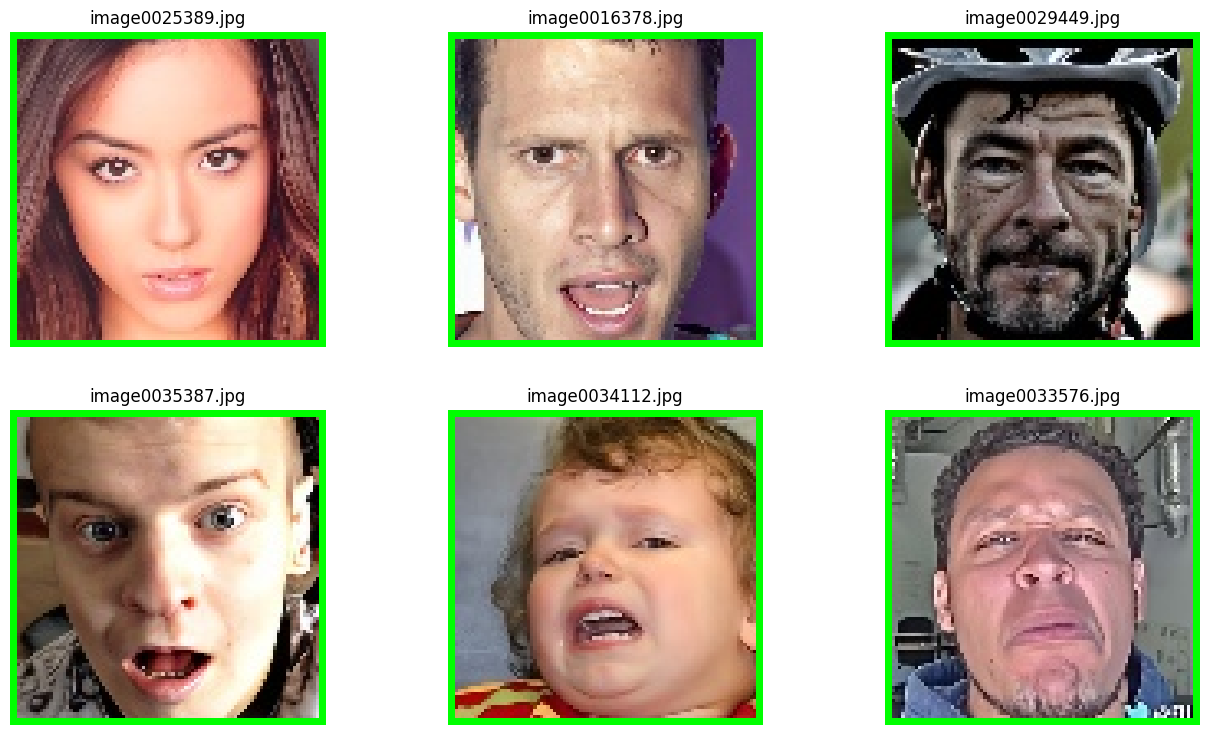

In [ ]:
import random, cv2, matplotlib.pyplot as plt

def draw_yolo_boxes(imgp, labelp):
    img = cv2.imread(imgp)
    if img is None:
        return None
    h,w = img.shape[:2]
    if os.path.exists(labelp):
        for line in open(labelp, errors='ignore'):
            parts = line.strip().split()
            if len(parts) < 5: continue
            c,x,y,ww,hh = map(float, parts[:5])
            x1 = int((x - ww/2)*w); y1 = int((y - hh/2)*h)
            x2 = int((x + ww/2)*w); y2 = int((y + hh/2)*h)
            cv2.rectangle(img, (max(0,x1),max(0,y1)), (min(w,x2),min(h,y2)), (0,255,0), 2)
            cv2.putText(img, str(int(c)), (max(0,x1), max(0,y1)-6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
    return img[:,:,::-1]

cands = glob.glob(os.path.join(base, 'train', 'images', '*'))
random.shuffle(cands)
samples = cands[:6]
plt.figure(figsize=(16,9))
for i,p in enumerate(samples):
    lbl = os.path.join(base, 'train', 'labels', os.path.splitext(os.path.basename(p))[0] + '.txt')
    img = draw_yolo_boxes(p,lbl)
    if img is None:
        continue
    plt.subplot(2,3,i+1); plt.imshow(img); plt.title(os.path.basename(p)); plt.axis('off')
plt.show()


# **Training**

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.2 MB/s eta 0:00:00


In [ ]:
!yolo --version

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ argument '--version' does not require leading dashes '--', updating to 'version'.
8.3.228


In [ ]:
!yolo task=detect mode=train \
    model=yolov8n.pt \
    data=/content/datasets/affectnet_yolo/YOLO_format/data.yaml \
    epochs=30 \
    imgsz=640 \
    batch=16 \
    project=./runs \
    name=affectnet_train


Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/affectnet_yolo/YOLO_format/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=affectnet_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,